# Avaliação de Modelos: K-Fold, Stratified K-Fold e Métricas Multi-Classe

Na última aula vimos:

1. **Reamostragem** --- como obter estimativas estáveis do erro de generalização sem desperdiçar dados (K-Fold, Stratified K-Fold, bootstrap).
2. **Métricas de classificação** --- accuracy, precision, recall e F1, com a distinção entre **micro** e **macro** que aparece no caso multi-classe.

Este notebook fecha o ciclo: vamos treinar um classificador de fato no dataset **Iris** (3 classes, multi-classe natural), monitorar a curva de perda durante o treinamento, e construir um pipeline completo de validação cruzada com `scikit-learn`. O modelo é o `SGDClassifier` com `loss='log_loss'` --- a versão *gradiente descendente estocástico* (SGD) da regressão logística que vimos no notebook 03, mas agora multinomial.

Plano:
1. Carregar o Iris e configurar o `SGDClassifier`;
2. Treinar com `partial_fit` e **plotar a curva de log-loss** por época;
3. Avaliar com **K-Fold** padrão;
4. Avaliar com **Stratified K-Fold** e comparar os dois;
5. Provocar um cenário **desbalanceado** para mostrar onde a estratificação realmente importa;
6. Discutir **precision e recall micro vs macro** em problemas multi-classe (com exemplo numérico);
7. Pipeline final usando `cross_validate` com várias métricas;
8. Resumo.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    KFold, StratifiedKFold, cross_validate, train_test_split
)
from sklearn.metrics import (
    accuracy_score, log_loss, precision_recall_fscore_support, classification_report
)

%matplotlib inline
import sklearn
print('sklearn version:', sklearn.__version__)
np.random.seed(42)

sklearn version: 1.8.0


---
## 1. Setup: Iris e o modelo de gradiente descendente

O dataset Iris tem $n = 150$ flores em **três classes balanceadas** (`setosa`, `versicolor`, `virginica`), com 50 amostras por classe e 4 features (largura/comprimento de sépala e pétala). É um caso multi-classe natural --- justamente o que precisamos para discutir métricas micro vs macro.

In [3]:
iris = load_iris()
X = iris.data            # (150, 4)
y = iris.target           # 0=setosa, 1=versicolor, 2=virginica
target_names = iris.target_names

# Distribuição de classes
counts = pd.Series(y).value_counts().sort_index()
print('classes:', list(target_names))
print('contagem por classe:')
print(counts.rename(index=dict(enumerate(target_names))))

classes: ['setosa', 'versicolor', 'virginica']
contagem por classe:
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


### O modelo: `SGDClassifier(loss='log_loss')`

O `SGDClassifier` do `scikit-learn` é um classificador linear treinado por **gradiente descendente estocástico** (SGD). Com `loss='log_loss'`, ele minimiza exatamente a mesma loss que vimos no notebook 03 --- a log-loss da regressão logística --- só que aqui no regime *estocástico* (atualiza $\boldsymbol{\theta}$ a cada amostra ou mini-batch, em vez de calcular o gradiente exato sobre todo o dataset a cada iteração).

Como Iris tem 3 classes, o `SGDClassifier` faz internamente um esquema **one-vs-rest** (OvR): treina 3 classificadores binários, um por classe, e na predição escolhe a classe com maior pontuação.

---
## 2. Curva de perda durante o treinamento

O `SGDClassifier` não expõe automaticamente um histórico de perda. Mas podemos rodar o treinamento **época a época** com `partial_fit` e calcular a log-loss manualmente, tanto no treino quanto em um conjunto de validação separado. Isso nos dá uma visão honesta da dinâmica do otimizador.

In [4]:
# Holdout simples só para monitorar a perda durante o treinamento.
# (NÃO é o pipeline final --- esse virá com K-Fold mais à frente.)
X_tr, X_val, y_tr, y_val = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

scaler = StandardScaler().fit(X_tr)
X_tr_s  = scaler.transform(X_tr)
X_val_s = scaler.transform(X_val)

sgd = SGDClassifier(loss='log_loss', random_state=42, learning_rate='constant', eta0=0.05)

n_epochs = 50
train_losses, val_losses = [], []
classes = np.array([0, 1, 2])

for epoch in range(n_epochs):
    # Embaralha as amostras a cada época (mimetiza SGD verdadeiro)
    perm = np.random.permutation(len(X_tr_s))
    sgd.partial_fit(X_tr_s[perm], y_tr[perm], classes=classes)
    train_losses.append(log_loss(y_tr,  sgd.predict_proba(X_tr_s),  labels=classes))
    val_losses.append(  log_loss(y_val, sgd.predict_proba(X_val_s), labels=classes))

print(f'log-loss final no treino:    {train_losses[-1]:.4f}')
print(f'log-loss final na validação: {val_losses[-1]:.4f}')

log-loss final no treino:    0.2185
log-loss final na validação: 0.3117


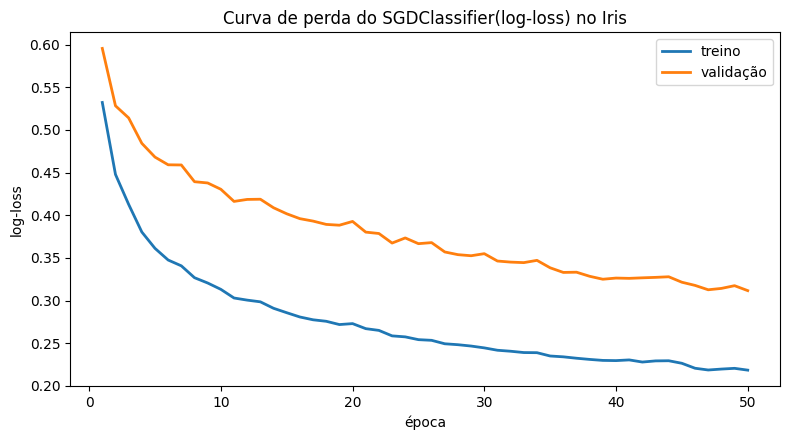

In [4]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(range(1, n_epochs + 1), train_losses, label='treino',     color='tab:blue',   linewidth=2)
ax.plot(range(1, n_epochs + 1), val_losses,   label='validação',  color='tab:orange', linewidth=2)
ax.set_xlabel('época')
ax.set_ylabel('log-loss')
ax.set_title('Curva de perda do SGDClassifier(log-loss) no Iris')
ax.legend()
plt.tight_layout(); plt.show()

Note como as duas curvas caem juntas (sem grande gap entre treino e validação), o que indica que **não há overfitting** neste setup --- o modelo é simples (linear) e o dataset é fácil. Em problemas mais difíceis, esperamos ver a perda de treino continuar caindo enquanto a de validação estabiliza ou sobe (assinatura clássica de overfitting). É exatamente esse comportamento que motiva os métodos de validação dos próximos slides.

---
## 3. K-Fold Cross-Validation

Em vez de confiar em um único split treino/teste --- cuja estimativa de erro varia bastante dependendo do sorteio --- usamos K-Fold: dividimos $\mathcal{D}$ em $K$ partes (*folds*), e a cada iteração uma das partes vira validação e as outras $K - 1$ formam o treino. A estimativa final é a média sobre os $K$ folds.

API do sklearn: `KFold(n_splits=K, shuffle=True, random_state=...)` gera os índices; iteramos sobre eles e treinamos um modelo por fold.

In [5]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Usamos Pipeline para que o StandardScaler seja AJUSTADO apenas no treino
# de cada fold (evita data leakage da validação para o treino).
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('sgd',    SGDClassifier(loss='log_loss', random_state=42, max_iter=1000, tol=1e-4)),
])

kf_scores = []
for fold, (idx_tr, idx_val) in enumerate(kf.split(X, y), start=1):
    pipe.fit(X[idx_tr], y[idx_tr])
    acc = pipe.score(X[idx_val], y[idx_val])
    kf_scores.append(acc)
    print(f'fold {fold}: acurácia = {acc:.4f}')

print(f'\nacurácia média (K-Fold):       {np.mean(kf_scores):.4f}')
print(f'desvio padrão (K-Fold):         {np.std(kf_scores, ddof=1):.4f}')

fold 1: acurácia = 0.8333
fold 2: acurácia = 0.9333
fold 3: acurácia = 0.9333
fold 4: acurácia = 0.9000
fold 5: acurácia = 0.9667

acurácia média (K-Fold):       0.9133
desvio padrão (K-Fold):         0.0506


---
## 4. Stratified K-Fold Cross-Validation

A variante **estratificada** preserva a proporção de classes em cada fold --- importante quando o dataset é desbalanceado (e desejável mesmo quando é balanceado, como o Iris, porque elimina o risco de algum fold ter classes ausentes por puro azar do sorteio).

Para entender visualmente a diferença, vamos comparar a distribuição de classes em cada fold sob `KFold` vs `StratifiedKFold`.

In [6]:
def class_dist_per_fold(splitter, X, y, n_classes=3):
    """Tabela com a contagem de cada classe nos folds de validação."""
    table = []
    for fold, (_, idx_val) in enumerate(splitter.split(X, y), start=1):
        row = {f'classe {c}': int((y[idx_val] == c).sum()) for c in range(n_classes)}
        row['fold'] = fold
        table.append(row)
    return pd.DataFrame(table).set_index('fold')

kf  = KFold(n_splits=5, shuffle=True, random_state=42)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print('=== KFold padrão ===')
print(class_dist_per_fold(kf, X, y))
print('\n=== Stratified K-Fold ===')
print(class_dist_per_fold(skf, X, y))

=== KFold padrão ===
      classe 0  classe 1  classe 2
fold                              
1           10         9        11
2           13        10         7
3           12        10         8
4            8        10        12
5            7        11        12

=== Stratified K-Fold ===
      classe 0  classe 1  classe 2
fold                              
1           10        10        10
2           10        10        10
3           10        10        10
4           10        10        10
5           10        10        10


No Iris balanceado, as duas distribuições já saem parecidas, mas note que o Stratified K-Fold tem **exatamente $10$ amostras por classe** em cada fold (porque cada classe tem $50$ amostras e $50/5 = 10$). O KFold padrão flutua: alguns folds têm $9$ ou $11$ de uma classe e $9$ ou $11$ de outra, dependendo do sorteio.

Rodando o pipeline com Stratified K-Fold:

In [7]:
skf_scores = []
for fold, (idx_tr, idx_val) in enumerate(skf.split(X, y), start=1):
    pipe.fit(X[idx_tr], y[idx_tr])
    acc = pipe.score(X[idx_val], y[idx_val])
    skf_scores.append(acc)
    print(f'fold {fold}: acurácia = {acc:.4f}')

print(f'\nacurácia média (Stratified):    {np.mean(skf_scores):.4f}')
print(f'desvio padrão (Stratified):      {np.std(skf_scores, ddof=1):.4f}')

fold 1: acurácia = 0.9667
fold 2: acurácia = 0.9000
fold 3: acurácia = 0.8333
fold 4: acurácia = 0.9667
fold 5: acurácia = 0.7667

acurácia média (Stratified):    0.8867
desvio padrão (Stratified):      0.0869


---
## 5. Por que estratificar? Iris desbalanceado

Quando o dataset é balanceado, as duas estratégias quase coincidem. A força do **Stratified K-Fold** aparece em datasets **desbalanceados**, onde um fold sem nenhuma amostra de uma classe minoritária seria desastroso (o modelo nunca veria essa classe no treino *ou* nunca seria avaliado nela).

Vamos provocar esse cenário artificialmente: manter as 50 amostras de `versicolor` e `virginica`, mas reduzir `setosa` para apenas $10$ amostras.

In [8]:
rng = np.random.default_rng(0)

# Mantém todas as classes 1 e 2; reduz a classe 0 para 10 amostras
mask_0 = (y == 0)
keep_0 = rng.choice(np.where(mask_0)[0], size=10, replace=False)
keep   = np.concatenate([keep_0, np.where(~mask_0)[0]])

X_imb = X[keep]
y_imb = y[keep]

print('distribuição original  vs. desbalanceada:')
print(pd.DataFrame({
    'original':       pd.Series(y).value_counts().sort_index(),
    'desbalanceada':  pd.Series(y_imb).value_counts().sort_index(),
}).rename(index=dict(enumerate(target_names))))

distribuição original  vs. desbalanceada:
            original  desbalanceada
setosa            50             10
versicolor        50             50
virginica         50             50


In [9]:
# Compara KFold vs Stratified em 10 sorteios distintos (vários random_state).
# Acumulamos acurácia média e desvio para cada estratégia.
def cv_summary(splitter_cls, X, y, n_repeats=10):
    accs_mean, accs_std = [], []
    for seed in range(n_repeats):
        splitter = splitter_cls(n_splits=5, shuffle=True, random_state=seed)
        fold_accs = []
        for idx_tr, idx_val in splitter.split(X, y):
            pipe.fit(X[idx_tr], y[idx_tr])
            fold_accs.append(pipe.score(X[idx_val], y[idx_val]))
        accs_mean.append(np.mean(fold_accs))
        accs_std.append(np.std(fold_accs, ddof=1))
    return np.array(accs_mean), np.array(accs_std)

kf_means, kf_stds   = cv_summary(KFold,           X_imb, y_imb)
skf_means, skf_stds = cv_summary(StratifiedKFold, X_imb, y_imb)

print(f'KFold       :  acurácia média = {kf_means.mean():.4f},  std intra-rodada média = {kf_stds.mean():.4f}')
print(f'Stratified  :  acurácia média = {skf_means.mean():.4f},  std intra-rodada média = {skf_stds.mean():.4f}')
print(f'\nVariação da acurácia entre os 10 sorteios:')
print(f'  KFold       : std = {kf_means.std(ddof=1):.4f}')
print(f'  Stratified  : std = {skf_means.std(ddof=1):.4f}')

KFold       :  acurácia média = 0.8336,  std intra-rodada média = 0.0919
Stratified  :  acurácia média = 0.8655,  std intra-rodada média = 0.0734

Variação da acurácia entre os 10 sorteios:
  KFold       : std = 0.0324
  Stratified  : std = 0.0170


O Stratified K-Fold tipicamente apresenta variação menor entre sorteios (números à direita) e menor desvio padrão entre folds dentro da mesma rodada (números à esquerda). Isso é exatamente o efeito que esperávamos: ao garantir que cada fold tem a mesma composição de classes, eliminamos uma fonte de variabilidade que o KFold padrão deixa solta. Em datasets ainda mais desbalanceados (e.g., $99\%/1\%$), a diferença vira gritante.

---
## 6. Precision e Recall em multi-classe: micro vs macro

No notebook 05 e nos slides vimos precision e recall para classificação **binária**. Em multi-classe (3 ou mais classes), precision e recall são definidas **por classe** --- calculamos uma versão para cada classe $k$ usando o esquema *one-vs-rest*:
$$
\text{precision}_k = \frac{TP_k}{TP_k + FP_k}, \qquad \text{recall}_k = \frac{TP_k}{TP_k + FN_k}.
$$

Para reportar **um único número**, agregamos as métricas por classe. As duas formas mais usadas são:

- **Macro**: média aritmética entre classes. Trata todas as classes igualmente, independentemente do tamanho:
$$
\text{precision}_{\text{macro}} \;=\; \frac{1}{g}\sum_{k=1}^{g} \text{precision}_k.
$$
- **Micro**: agrega TPs, FPs, FNs de todas as classes antes de aplicar a fórmula:
$$
\text{precision}_{\text{micro}} \;=\; \frac{\sum_k TP_k}{\sum_k (TP_k + FP_k)}.
$$

**Fato importante**: em classificação multi-classe *single-label* (cada amostra tem exatamente um rótulo --- o caso padrão), $\sum_k FP_k = \sum_k FN_k$ porque todo FP de uma classe é FN de outra. Isso faz com que $\text{precision}_{\text{micro}} = \text{recall}_{\text{micro}} = \text{accuracy}$ exatamente. Em outras palavras, **as três métricas "micro" colapsam na acurácia** nesse cenário.

In [10]:
# Exemplo numérico minúsculo para fixar a diferença.
# 3 classes (A, B, C), 10 amostras, com classe C subrepresentada (apenas 1 amostra)
y_true = np.array(['A','A','A','A','B','B','B','B','B','C'])
y_pred = np.array(['A','A','A','B','B','B','B','C','A','A'])  # erros variados

# Per classe
prec, rec, f1, sup = precision_recall_fscore_support(
    y_true, y_pred, labels=['A', 'B', 'C'], zero_division=0
)
per_class = pd.DataFrame({
    'precision': prec, 'recall': rec, 'f1': f1, 'support': sup
}, index=['A', 'B', 'C'])
print('Por classe:'); print(per_class.round(3))

# Agregações
for avg in ['macro', 'weighted', 'micro']:
    p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, average=avg, zero_division=0)
    print(f'\n{avg:8s}: precision={p:.3f}  recall={r:.3f}  f1={f:.3f}')

print(f'\naccuracy = {accuracy_score(y_true, y_pred):.3f}  '
      f'(= precision_micro = recall_micro)')

Por classe:
   precision  recall     f1  support
A       0.60    0.75  0.667        4
B       0.75    0.60  0.667        5
C       0.00    0.00  0.000        1

macro   : precision=0.450  recall=0.450  f1=0.444

weighted: precision=0.615  recall=0.600  f1=0.600

micro   : precision=0.600  recall=0.600  f1=0.600

accuracy = 0.600  (= precision_micro = recall_micro)


Note duas coisas no exemplo:

1. A classe **C** tem $\text{recall} = 0$ porque a única amostra de C foi rotulada como A (não detectamos ela). Na média **macro**, esse zero puxa muito o recall geral para baixo ($\approx 0{,}40$).
2. Na média **micro** (igual à acurácia, $0{,}50$), o desempenho ruim em C é diluído pelos acertos nas outras classes maiores.

**Quando usar cada?**
- **Macro**: quando todas as classes importam igualmente, mesmo as minoritárias. Padrão em problemas científicos, médicos, ou onde a classe minoritária é justamente a interessante (fraude, doença rara). Penaliza o modelo por ser ruim em classes pequenas.
- **Weighted**: macro ponderado pelo `support` (número de amostras verdadeiras por classe). Compromisso entre os dois.
- **Micro**: quando o que importa é a fração total de acertos, sem dar peso especial a nenhuma classe. Em single-label, equivale à acurácia.

A escolha **não** é técnica --- é uma decisão de produto sobre o que conta como "bom modelo" no seu contexto.

---
## 7. Pipeline completo: SGD + Stratified K-Fold + métricas

Agora juntamos tudo. Usamos a função `cross_validate` do `sklearn`, que aceita uma lista de *scorers* e retorna um dicionário com o score em cada fold para cada métrica.

In [9]:
scoring = [
    'accuracy',
    'precision_macro', 'precision_micro', 'precision_weighted',
    'recall_macro',    'recall_micro',    'recall_weighted',
    'f1_macro',        'f1_micro',        'f1_weighted',
]

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('sgd',    SGDClassifier(loss='log_loss', random_state=42, max_iter=1000, tol=1e-4)),
])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = cross_validate(pipe, X, y, cv=skf, scoring=scoring, return_train_score=False)

# Organiza em DataFrame: linhas = métricas, colunas = média ± desvio
summary = pd.DataFrame({
    'média': [results[f'test_{s}'].mean()        for s in scoring],
    'desvio': [results[f'test_{s}'].std(ddof=1)   for s in scoring],
}, index=scoring).round(4)
print(summary)

                     média  desvio
accuracy            0.8867  0.0869
precision_macro     0.9123  0.0611
precision_micro     0.8867  0.0869
precision_weighted  0.9123  0.0611
recall_macro        0.8867  0.0869
recall_micro        0.8867  0.0869
recall_weighted     0.8867  0.0869
f1_macro            0.8778  0.0996
f1_micro            0.8867  0.0869
f1_weighted         0.8778  0.0996


In [10]:
# Sanity check do fato teórico: precision_micro == recall_micro == accuracy
acc        = results['test_accuracy']
prec_micro = results['test_precision_micro']
rec_micro  = results['test_recall_micro']

print('Por fold:')
for i in range(len(acc)):
    print(f'  fold {i+1}: accuracy={acc[i]:.4f}, prec_micro={prec_micro[i]:.4f}, '
          f'rec_micro={rec_micro[i]:.4f}')
print(f'\ntodos batem? {np.allclose(acc, prec_micro) and np.allclose(acc, rec_micro)}')

Por fold:
  fold 1: accuracy=0.9667, prec_micro=0.9667, rec_micro=0.9667
  fold 2: accuracy=0.9000, prec_micro=0.9000, rec_micro=0.9000
  fold 3: accuracy=0.8333, prec_micro=0.8333, rec_micro=0.8333
  fold 4: accuracy=0.9667, prec_micro=0.9667, rec_micro=0.9667
  fold 5: accuracy=0.7667, prec_micro=0.7667, rec_micro=0.7667

todos batem? True


Confirmado: as três métricas micro colapsam para a acurácia em single-label, exatamente como a teoria prevê. Na prática, ao reportar resultados de um classificador multi-classe, o ideal é mostrar **macro** (para enxergar problemas em classes minoritárias) e **accuracy** (= micro). Reportar "precision micro" e "precision macro" lado a lado é redundante quando a única diferença real é o esquema de agregação.

### 7.1 Relatório completo do último fold

Para fechar, o `classification_report` do `sklearn` reporta automaticamente todas as métricas por classe junto com os agregados macro e weighted:

In [11]:
# Pega o último split e treina/testa para gerar um relatório legível
*_, (idx_tr, idx_val) = skf.split(X, y)
pipe.fit(X[idx_tr], y[idx_tr])
y_pred_last = pipe.predict(X[idx_val])

print(classification_report(
    y[idx_val], y_pred_last, target_names=target_names, digits=3
))

              precision    recall  f1-score   support

      setosa      1.000     1.000     1.000        10
  versicolor      0.588     1.000     0.741        10
   virginica      1.000     0.300     0.462        10

    accuracy                          0.767        30
   macro avg      0.863     0.767     0.734        30
weighted avg      0.863     0.767     0.734        30



---
## 8. Resumo

| Conceito | O que faz | Quando usar |
|---|---|---|
| `SGDClassifier(loss='log_loss')` | Regressão logística por gradiente descendente estocástico (versão `sklearn` do nb. 03) | Datasets grandes; quando queremos atualizações incrementais via `partial_fit` |
| Curva de log-loss por época | Diagnóstico visual da dinâmica de otimização (treino e validação) | Para detectar overfitting (val sobe) ou underfitting (ambas estagnam alto) |
| **K-Fold** | Particiona $\mathcal{D}$ em $K$ folds, cada um sendo validação uma vez | Default para reduzir variância da estimativa quando há pouco dado |
| **Stratified K-Fold** | K-Fold preservando proporção de classes em cada fold | Sempre que o problema é classificação --- crítico se desbalanceado |
| **Pipeline** ($\texttt{StandardScaler}$ + classificador) | Encapsula pré-processamento + modelo; garante que o scaler é ajustado *só* no treino de cada fold | Sempre que houver pré-processamento dependente de dados |
| `cross_validate(..., scoring=[...])` | Roda CV uma vez e retorna múltiplas métricas | Para comparar accuracy / precision / recall / F1 em uma chamada |
| **Macro vs micro** | Macro $=$ média aritmética entre classes; micro $=$ contagens agregadas. Em single-label, $\text{micro} = \text{accuracy}$ | Macro: classes igualmente importantes (minoritárias contam). Micro: importa o total |

Três tomadas-de-conclusão deste notebook:

1. **Pipeline correto**. Quando há scaler (ou qualquer pré-processamento dependente de dados), use `sklearn.pipeline.Pipeline` para evitar data leakage durante CV. O scaler em cada fold deve ser ajustado **só** no treino do fold.
2. **Estratificação é gratuita e protege contra azar do sorteio**. Mesmo quando o dataset é balanceado, `StratifiedKFold` produz folds mais consistentes. Em desbalanceado, é essencialmente obrigatório.
3. **Em multi-classe single-label, micro = accuracy**. Saber disso evita reportar números redundantes. Para enxergar problemas em classes minoritárias, sempre olhe **macro** ou per-classe.